### Import Libraries

Date: 2026-07-25

Student ID: DAMHAR2570

### Load Dataset

### Clean Data

Missing values per column:
id                    0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Summary Statistics:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   344.000000  
mean   2008.029070  
std       0

### Histograms

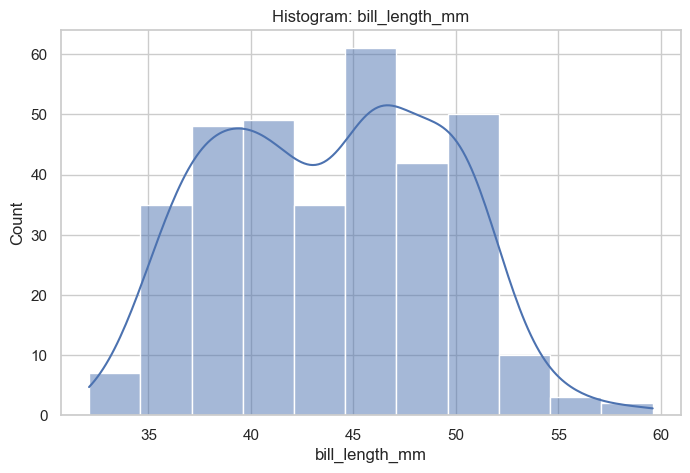

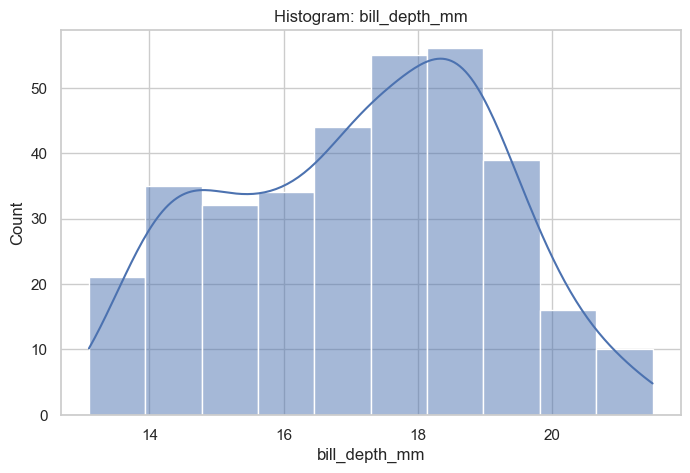

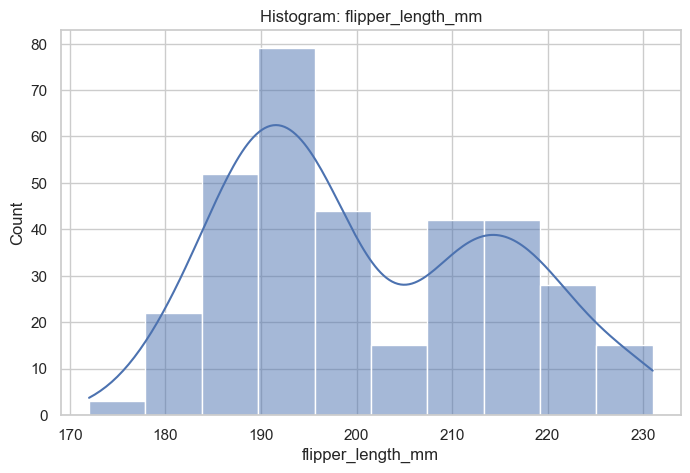

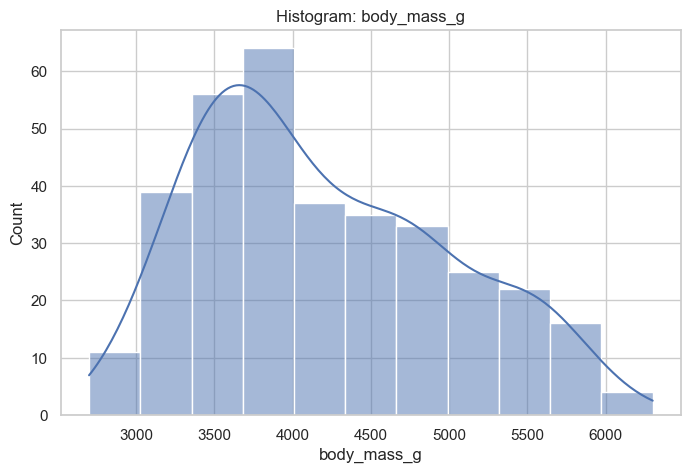

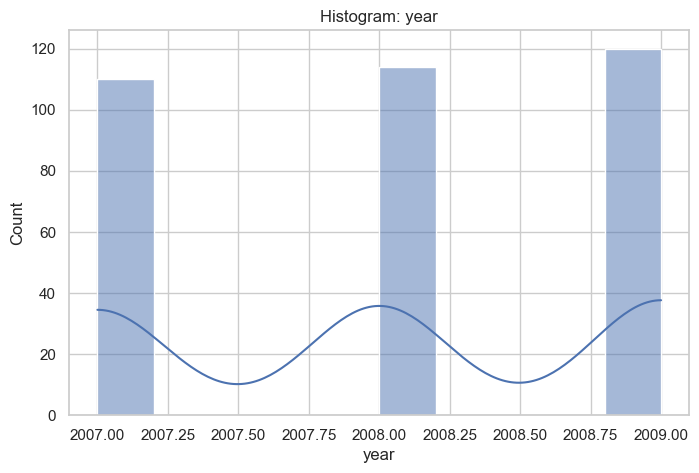

### Boxplots

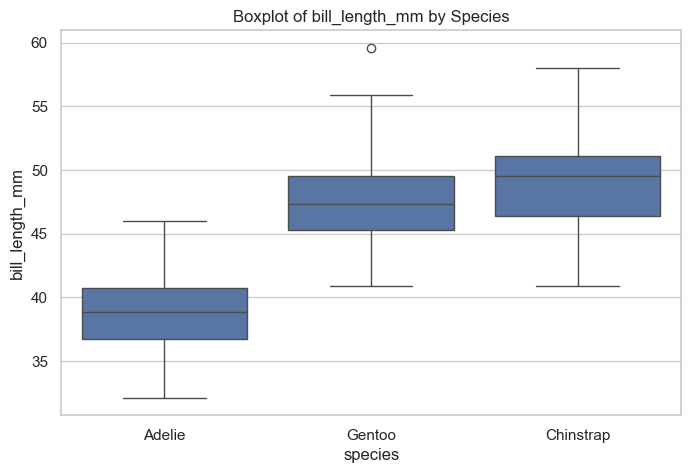

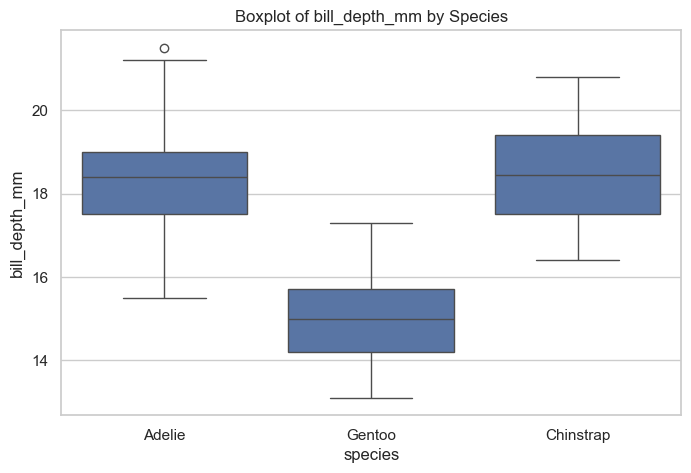

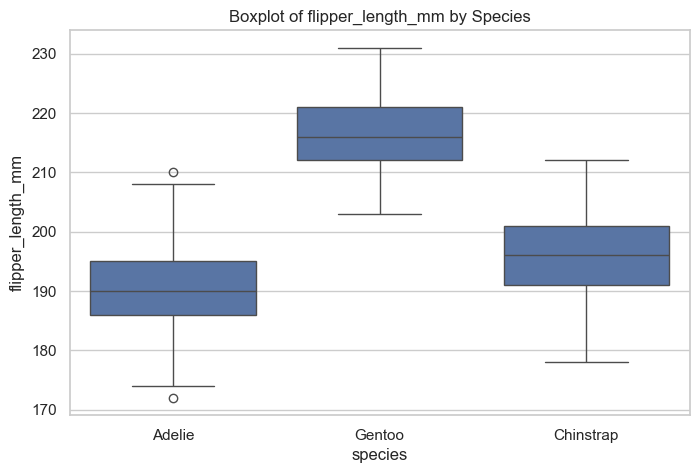

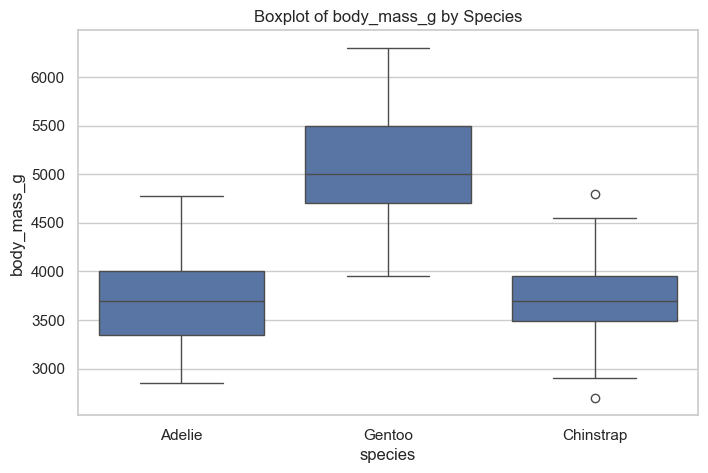

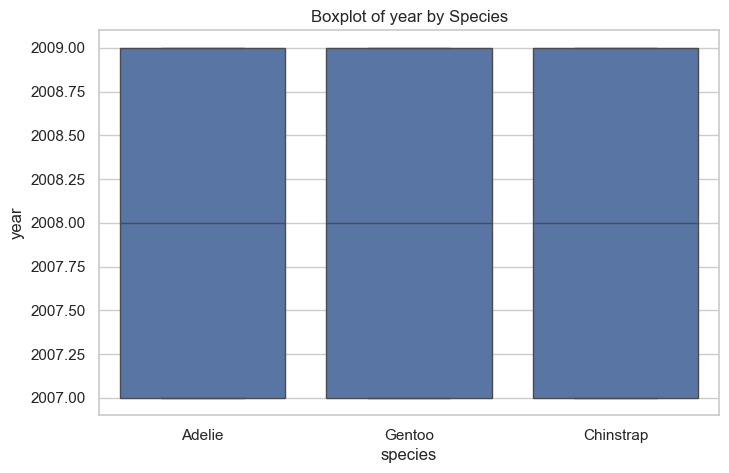

### Correlation Matrix and Heatmap


Correlation Matrix:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   
year                     0.054545      -0.060354           0.169675   

                   body_mass_g      year  
bill_length_mm        0.595110  0.054545  
bill_depth_mm        -0.471916 -0.060354  
flipper_length_mm     0.871202  0.169675  
body_mass_g           1.000000  0.042209  
year                  0.042209  1.000000  


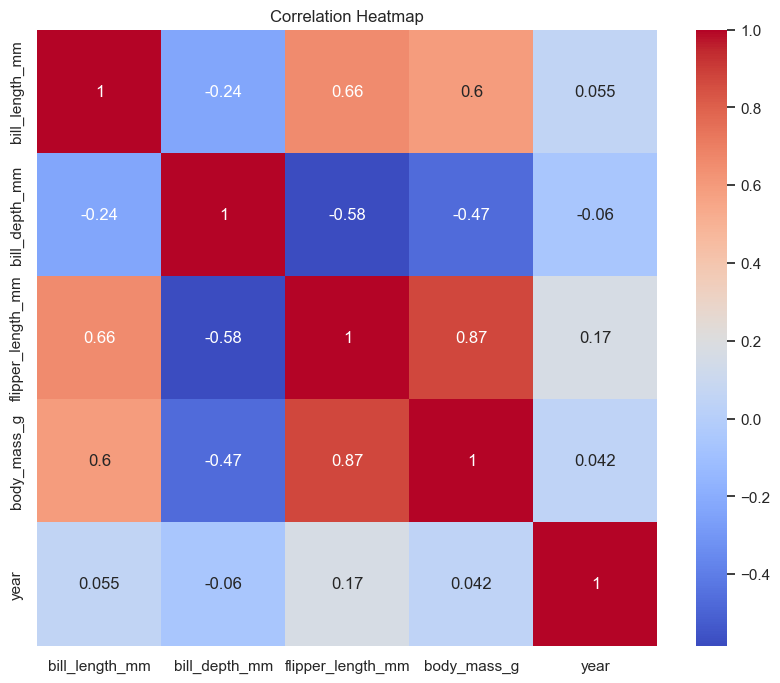

### Pairplot

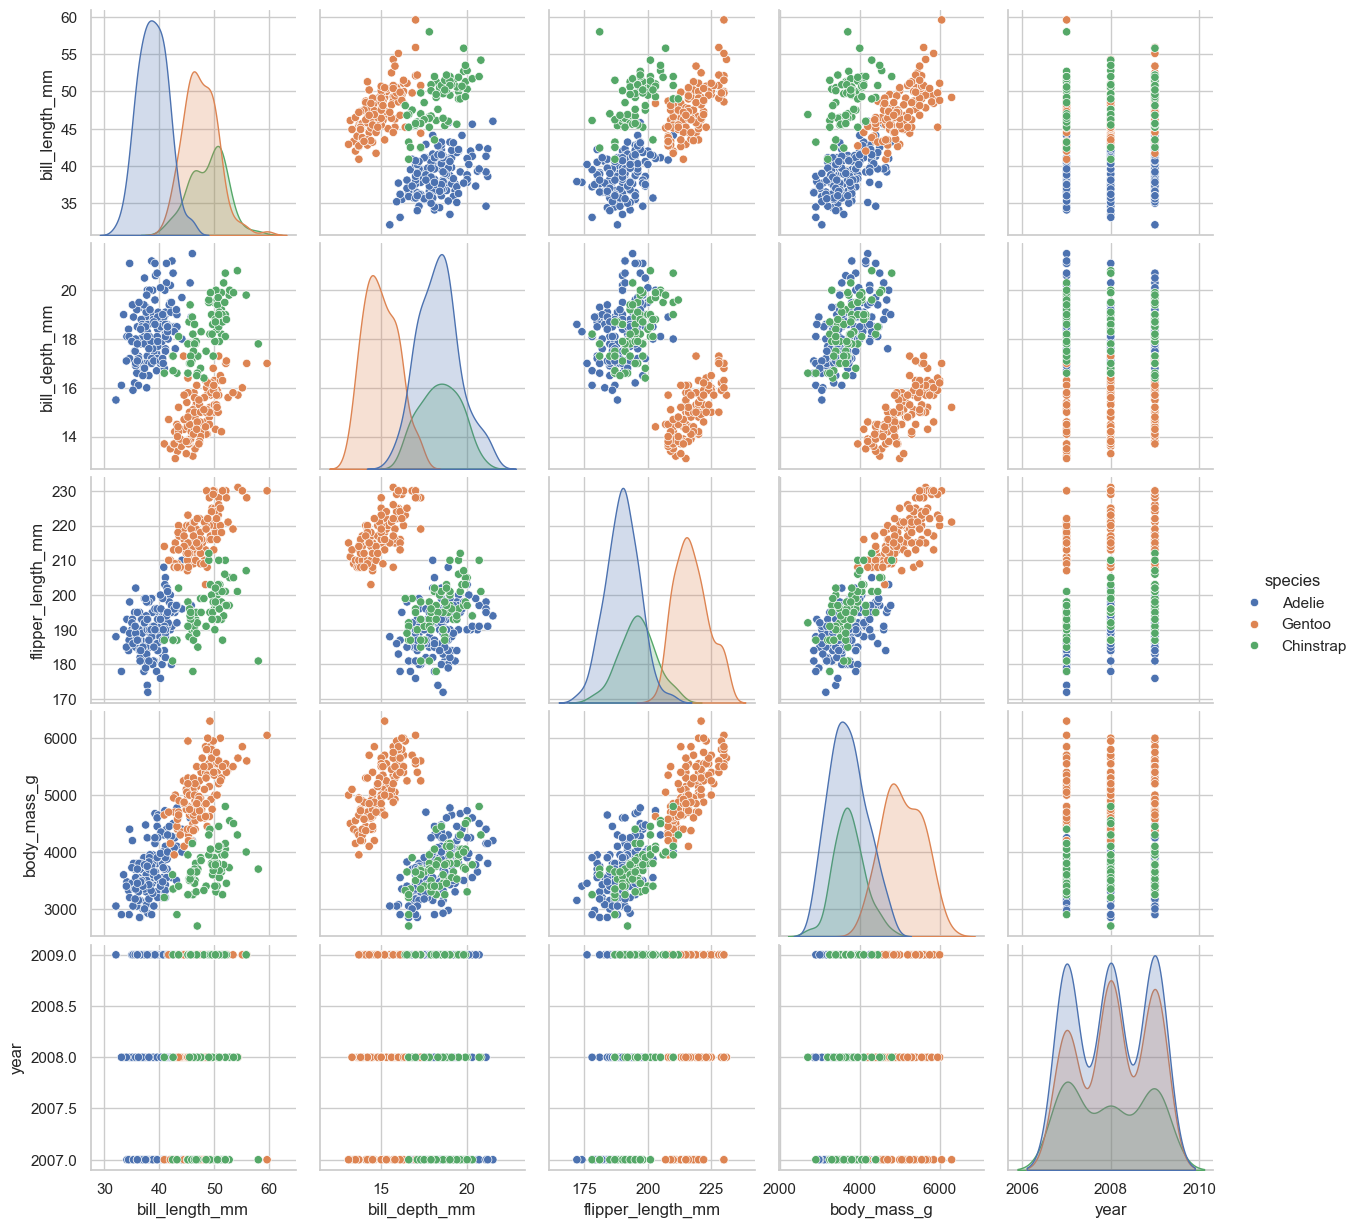

### Preprocessing for CNN


Rows before cleaning: 344
Rows after cleaning: 342


### PCA

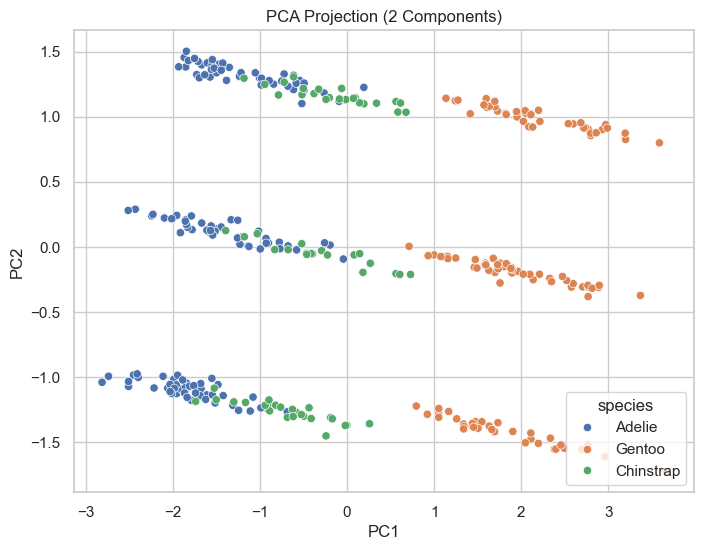

### Processed Dataset


Processed dataset shape: (342, 17)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from datetime import datetime
from IPython.display import display, Markdown

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"
display(Markdown("### Import Libraries"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Make plots pretty
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

display(Markdown("### Load Dataset"))
df = pd.read_csv("C:/Users/ecpi/Downloads/penguins.csv")

display(Markdown("### Clean Data"))
num_cols = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","year"]

# Convert to numeric, coerce errors
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Show missing counts
print("Missing values per column:")
print(df.isna().sum())

print("\nSummary Statistics:")
print(df[num_cols].describe())

display(Markdown("### Histograms"))
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram: {col}")
    plt.show()

display(Markdown("### Boxplots"))
for col in num_cols:
    plt.figure()
    sns.boxplot(x="species", y=col, data=df)
    plt.title(f"Boxplot of {col} by Species")
    plt.show()

display(Markdown("### Correlation Matrix and Heatmap"))
corr = df[num_cols].corr()
print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

display(Markdown("### Pairplot"))
sns.pairplot(df, vars=num_cols, hue="species")
plt.show()

display(Markdown("### Preprocessing for CNN"))

# ---- Drop rows with missing numeric values ----
df_clean = df.dropna(subset=num_cols)
print("\nRows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))

# ---- One-hot encode categorical features ----
df_encoded = pd.get_dummies(df_clean, columns=["species","island","sex"], dummy_na=True)

# ---- Standardize numeric features ----
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(df_encoded[num_cols])

# Replace numeric columns with scaled versions
df_encoded[num_cols] = scaled_numeric

display(Markdown("### PCA"))
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_encoded[num_cols])

pca_df = pd.DataFrame(pca_components, columns=["PC1","PC2"])
pca_df["species"] = df_clean["species"].values

# PCA scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="species", palette="deep")
plt.title("PCA Projection (2 Components)")
plt.show()

display(Markdown("### Processed Dataset"))
print("\nProcessed dataset shape:", df_encoded.shape)

3.2 Project Supervised and Unsupervised Machine Learning Models - 7/25/2026 - DAMHAR2570

In [2]:
display(Markdown("### Identify Features and Target"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Target: species (multiclass classification)
y_cls = df_clean["species"]   # Adelie / Gentoo / Chinstrap

# Features: all encoded columns except year (optional) and any target-like columns
X_cls = df_encoded.drop(columns=["year"])  # keep all numeric + one-hot features

print("Classification features shape:", X_cls.shape)
print("Target shape:", y_cls.shape)

display(Markdown("### Numerical Features for Clustering"))

num_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X_clust_raw = df_clean[num_features].dropna()

print("Clustering numeric features shape:", X_clust_raw.shape)

display(Markdown("### Train_Test_Split"))
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

### Identify Features and Target

Date: 2026-07-25

Student ID: DAMHAR2570

Classification features shape: (342, 16)
Target shape: (342,)


### Numerical Features for Clustering

Clustering numeric features shape: (342, 4)


### Train_Test_Split

Train size: 273
Test size: 69


### K-Nearest Neighbors

Date: 2026-07-25

Student ID: DAMHAR2570

=== KNN Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



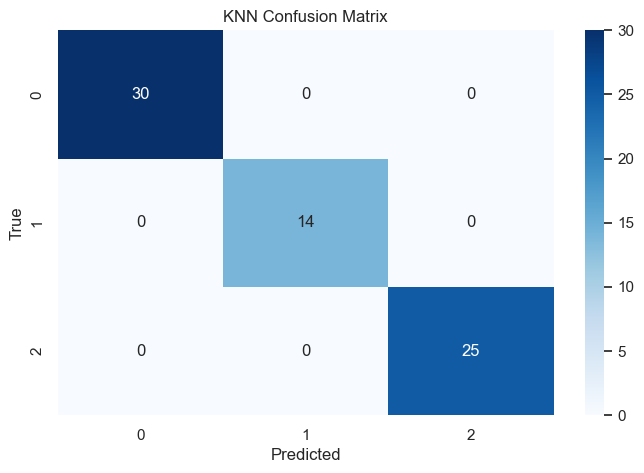

### Decision Tree

=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



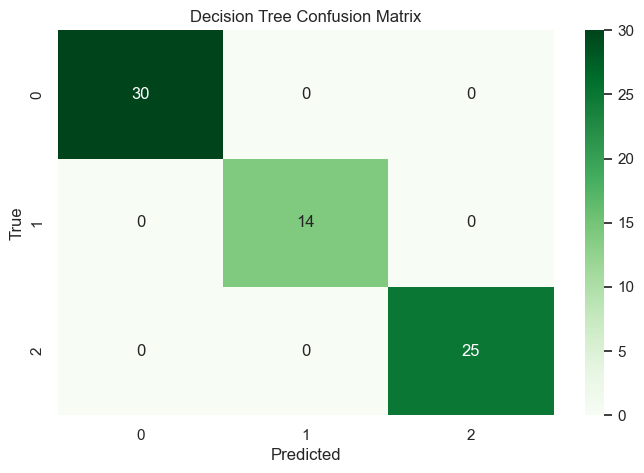

### Gradient Boosting

=== Gradient Boosting Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



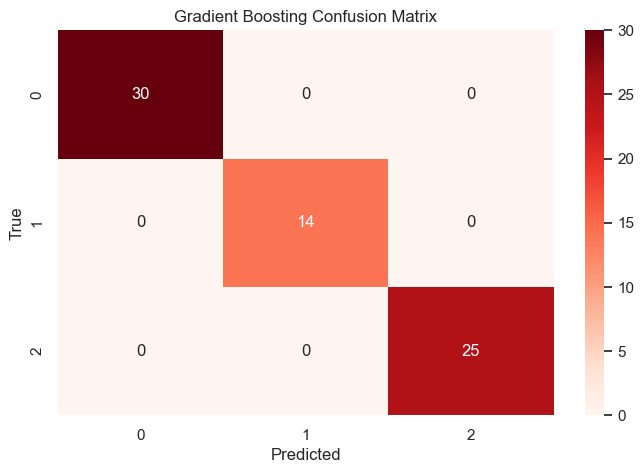

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

display(Markdown("### K-Nearest Neighbors"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

knn = KNeighborsClassifier(n_neighbors=5, weights="uniform")
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("=== KNN Classification Report ===")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure()
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

display(Markdown("### Decision Tree"))
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree Classification Report ===")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure()
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

display(Markdown("### Gradient Boosting"))
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("=== Gradient Boosting Classification Report ===")
print(classification_report(y_test, y_pred_gb))

cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure()
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Reds")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### GridsearchCV for KNN

Date: 2026-07-25

Student ID: DAMHAR2570

Best KNN parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best CV accuracy: 0.9963636363636365
=== Tuned KNN Classification Report ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



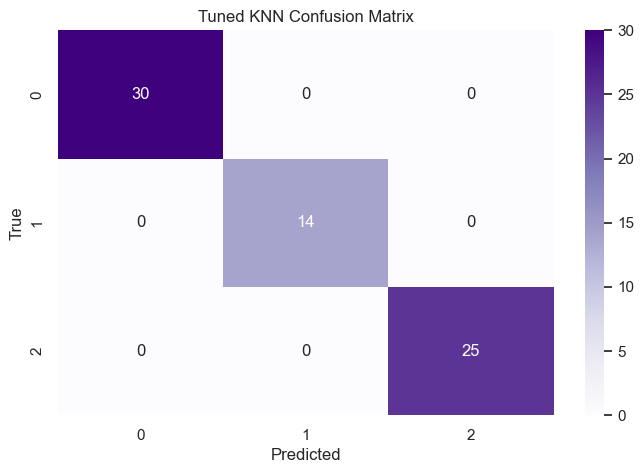

In [4]:
from sklearn.model_selection import GridSearchCV

display(Markdown("### GridsearchCV for KNN"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

param_grid = {
    "n_neighbors": [3,5,7,9,11],
    "weights": ["uniform", "distance"]
}

knn_base = KNeighborsClassifier()
grid_search = GridSearchCV(
    knn_base,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best KNN parameters:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

# Evaluate tuned KNN on test set
knn_best = grid_search.best_estimator_
y_pred_knn_best = knn_best.predict(X_test)

print("=== Tuned KNN Classification Report ===")
print(classification_report(y_test, y_pred_knn_best))

cm_knn_best = confusion_matrix(y_test, y_pred_knn_best)
plt.figure()
sns.heatmap(cm_knn_best, annot=True, fmt="d", cmap="Purples")
plt.title("Tuned KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Standardize Clustering Features

Date: 2026-07-25

Student ID: DAMHAR2570

### Hierarchical Cluster and Dendrogram

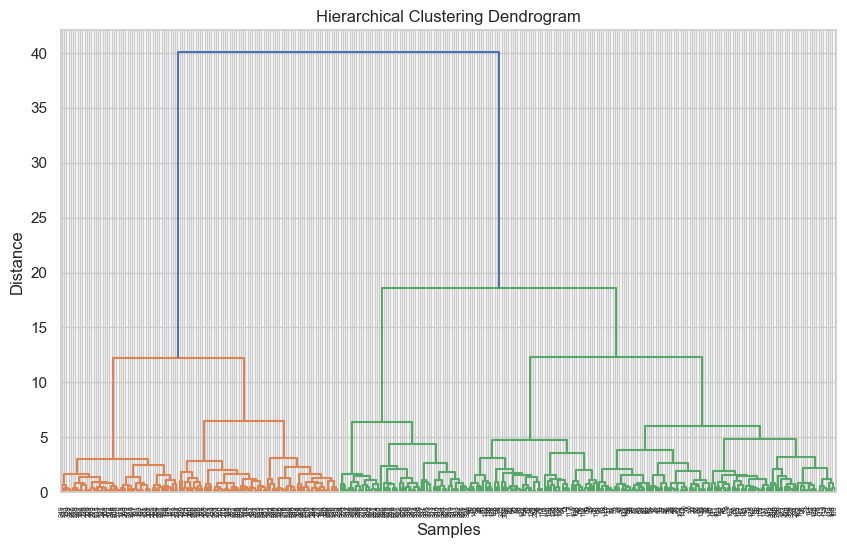

### K-Means Elbow Method

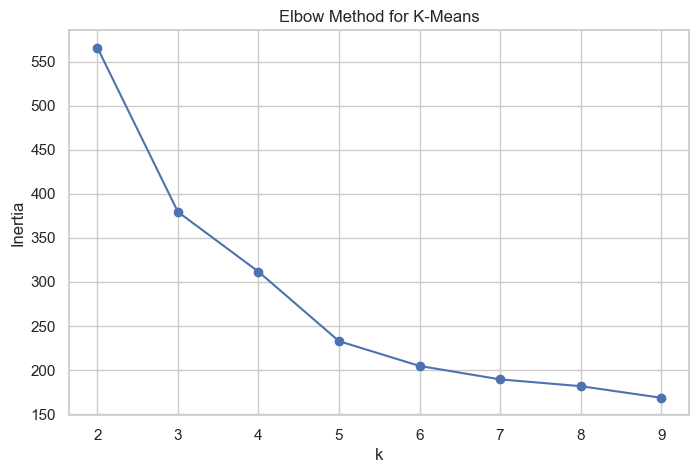

### Silhouette Score

k=2, silhouette=0.532
k=3, silhouette=0.447
k=4, silhouette=0.425
k=5, silhouette=0.380
k=6, silhouette=0.370
k=7, silhouette=0.321
k=8, silhouette=0.309
k=9, silhouette=0.299


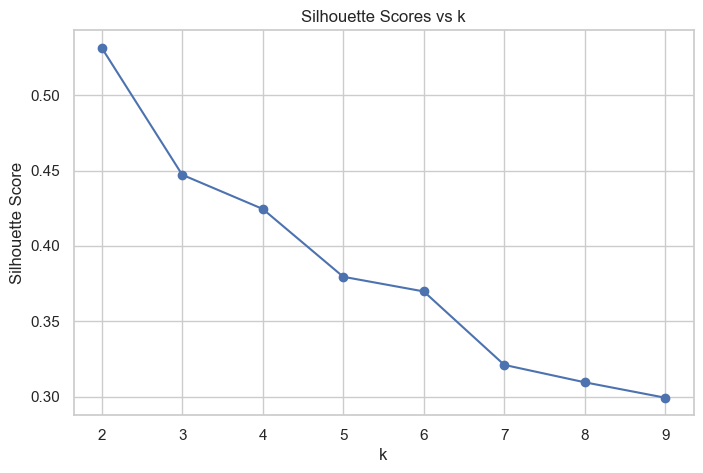

### Final K-Means Model

         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
cluster                                                               
0             47.525287      18.762069         196.896552  3902.011494
1             47.504878      14.982114         217.186992  5076.016260
2             38.208333      18.110606         188.401515  3584.659091


### Cluster Visualization

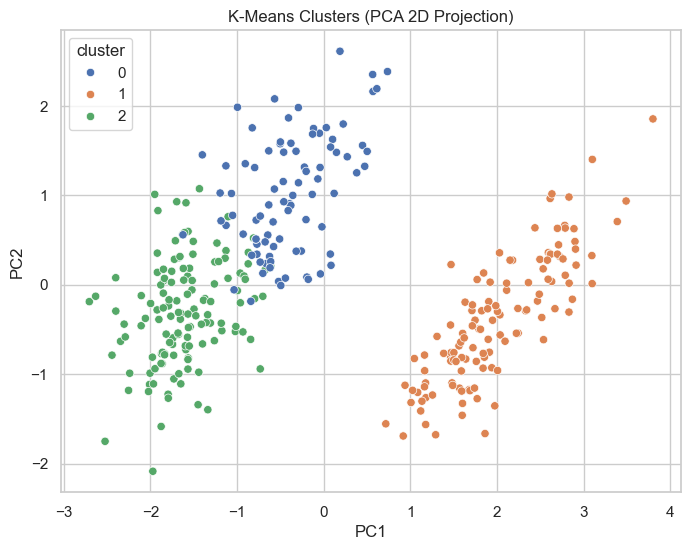

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

display(Markdown("### Standardize Clustering Features"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(X_clust_raw)

display(Markdown("### Hierarchical Cluster and Dendrogram"))
Z = linkage(X_clust, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

display(Markdown("### K-Means Elbow Method"))
inertias = []
k_values = range(2, 10)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_clust)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

display(Markdown("### Silhouette Score"))
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_clust)
    sil = silhouette_score(X_clust, labels)
    sil_scores.append(sil)
    print(f"k={k}, silhouette={sil:.3f}")

plt.figure()
plt.plot(k_values, sil_scores, marker="o")
plt.title("Silhouette Scores vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

display(Markdown("### Final K-Means Model"))
k_final = 3  # example; set based on your analysis
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
cluster_labels = kmeans_final.fit_predict(X_clust)

# Add cluster labels back to a DataFrame for interpretation
clust_df = X_clust_raw.copy()
clust_df["cluster"] = cluster_labels

print(clust_df.groupby("cluster").mean())

display(Markdown("### Cluster Visualization"))
pca_clust = PCA(n_components=2)
X_clust_pca = pca_clust.fit_transform(X_clust)

pca_clust_df = pd.DataFrame(X_clust_pca, columns=["PC1","PC2"])
pca_clust_df["cluster"] = cluster_labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_clust_df, x="PC1", y="PC2", hue="cluster", palette="deep")
plt.title("K-Means Clusters (PCA 2D Projection)")
plt.show()

Which classification model performed best, and why?
The K-Nearest Neighbor model performed the best with 100% accuracy.

Compare accuracy, precision/recall, and confusion matrices. Did GridSearchCV improve the KNN model?
The GridSearchCV did optimize the hyperparameters and increase the accuracy to 100%.

Compare baseline vs tuned KNN metrics. What does the dendrogram suggest about the number of clusters?
The large vertical jump connecting the groups at a higher distance indicates that there are three distinct groups. 

Look for big vertical jumps in linkage distance. What values of k are suggested by the Elbow Method and Silhouette Scores?
This suggests k=2 or k=3 is likely the optimal number.

Refer to plots and printed silhouette scores. What value of k did you select for the final model, and why?
k=3 was selected due to the Elbow having a distinct bend at 3 as well as the Silhouette score being highest at 3.

Justify using elbow + silhouette + interpretability. What patterns distinguish the final clusters?
Along with the elbow and silhouette the fact that the dataset has only three species supports the final cluster decision.

Use clust_df.groupby("cluster").mean() to describe differences in bill length, depth, flipper length, body mass. What limitations could affect the results?
The Adelie has a shorter bill shorter flippers and lower body mass. The Chinstrap has a long bill, medium flipper and medium body mass. The Gentoo has a medium bill, long flipper and highest body mass. The Chinstrap has fewer samples, Adelie dominates the dataset in the species category causing imbalance and noise is introduced by variations in researchers and conditions. These along with improper scaling  could be limiting factors that would affect results.
